In [20]:
import sys, subprocess

# Define uma função para instalar bibliotecas via pip install
def pip_install(pkgs):
  subprocess.check_call([sys.executable, "-m", "pip", "install"] + pkgs + ["-q"])

# Tenta importar a biblioteca xgboost, caso não consiga, chama a função para instalá-la
try:
  import xgboost as xgb
except:
  pip_install(["xgboost"])
  import xgboost as xgb


In [21]:
# Importação de bibliotecas
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re

In [8]:
# Carregando dataset
df = pd.read_csv("column_2C.dat", sep=r"\s+", header=None, engine="python")

In [10]:
# Renomeando as colunas
df.columns = [
    "pelvic_incidence",
    "pelvic_tilt",
    "lumbar_lordosis_angle",
    "sacral_slope",
    "pelvic_radius",
    "degree_spondylolisthesis",
    "class"
]

print(df.head())
print(df.shape)

   pelvic_incidence  pelvic_tilt  lumbar_lordosis_angle  sacral_slope  \
0             63.03        22.55                  39.61         40.48   
1             39.06        10.06                  25.02         29.00   
2             68.83        22.22                  50.09         46.61   
3             69.30        24.65                  44.31         44.64   
4             49.71         9.65                  28.32         40.06   

   pelvic_radius  degree_spondylolisthesis class  
0          98.67                     -0.25    AB  
1         114.41                      4.56    AB  
2         105.99                     -3.53    AB  
3         101.87                     11.21    AB  
4         108.17                      7.92    AB  
(310, 7)


In [12]:
# Limpeza e Mapeamento do dataset
def map_target_val(s):
  """
  Converte valores da colunas class em 0 (normal) ou 1 (abnormal)
  """

  if pd.isna(s):
    return np.nan

  s = str(s).strip().lower() # Converte para str, remove espaços irrelevantes e deixa tudo em minúsculo
  s_clean = re.sub("[^a-z0-9]", "", s) # Remove caracteres não alfanuméricos

  if "normal" in s_clean or s_clean in ("0", "no", "n"):
    return 0

  if "abnormal" in s_clean or "ab" in s_clean or "dh" in s_clean or "sl" in s_clean or "disk" in s_clean or "spondylolisthesis" in s_clean:
    return 1

  return np.nan # Retorna Nan se o valor não corresponder a nenhuma das classes

df["class_mapped"] = df["class"].apply(map_target_val)

if df["class_mapped"].isna().any():
  print("Rótulos não mapeados encontrados (serão removidos): ")
  print(df.loc[df["class_mapped"].isna(), "class"].unique())

n_bad = df["class_mapped"].isna().sum()

if n_bad > 0:
  print(f"Removendo {n_bad} linhas com rótulos inválidos")
  df = df[df["class_mapped"].isna()].reset_index(drop=True)

# Substituindo a coluna original pela versão numérica

df["class"] = df["class_mapped"].astype(int)
df = df.drop(columns=["class_mapped"])

print("\nDistribuição final das classes: ")
print(df["class"].value_counts())


Distribuição final das classes: 
class
1    210
0    100
Name: count, dtype: int64


In [13]:
# Garantindo que as 6 features sejam numéricas
feat_cols = [
    "pelvic_incidence",
    "pelvic_tilt",
    "lumbar_lordosis_angle",
    "sacral_slope",
    "pelvic_radius",
    "degree_spondylolisthesis"
]

for c in feat_cols:
  df[c] = pd.to_numeric(df[c], errors="coerce")

n_num_bad = df[feat_cols].isna().any(axis=1).sum()

if n_num_bad > 0:
  print(f"Removendo {n_num_bad} linhas com valores numéricos inválidos")
  df.dropna(subset=feat_cols).reset_index(drop=True)

print(f"\nApós a limpeza, shape: {df.shape}")



Após a limpeza, shape: (310, 7)


In [16]:
# Splits (treino, vaalidação e teste)

def safe_splits(df, test_size=0.2, val_size=0.25, random_state=42):
  """
  Divide o dataset em treino, validação e teste. Faz tentativaas seguras com e sem estratificação
  """

  try:
    train_full, test = train_test_split(
        df,
        test_size=test_size,
        stratify=df["class"],
        random_state=random_state
    )
  except Exception as e:
    print(f"Stratifed outer split falhou: {e} -> Usando split sem stratify")
    train_full, test = train_test_split(
        df,
        test_size=test_size,
        stratify=None,
        random_state=random_state
    )

  # Divide o train_full em treino e validação, novamente tentando usar estratificação
  try:
    train, val = train_test_split(
        train_full,
        test_size=val_size,
        stratify=train_full["class"],
        random_state=random_state
    )
  # Caso a estratificação falhe novamente, realiza split sem stratify
  except Exception as e:
    print(f"Stratifed inner split falhou: {e} -> Usando split sem stratify")
    train, val = train_test_split(
        train_full,
        test_size=val_size,
        stratify=None,
        random_state=random_state
    )

  return(
      train.reset_index(drop=True),
      val.reset_index(drop=True),
      test.reset_index(drop=True)
  )

# Executando o split utilizando a função criada
train, val, test = safe_splits(df)

print("\nTamanhos:")
print(f"Treino: {train.shape}\nValidação: {val.shape}\nTeste: {test.shape}")

if len(train) == 0 or len(val) == 0 or len(test) == 0:
  raise RuntimeError("Split resultou em um conjunto vazio. Verifique o dataset após a limpeza.")



Tamanhos:
Treino: (186, 7)
Validação: (62, 7)
Teste: (62, 7)


In [18]:
# Preparando features (X) e labels (Y)
x_train, y_train = train[feat_cols], train["class"]
x_val, y_val = val[feat_cols], val["class"]
x_test, y_test = test[feat_cols], test["class"]

print(f"\nExemplos {x_train.shape} {y_train.shape}")



Exemplos (186, 6) (186,)


In [23]:
# Criando um módulo XGBoost
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_staate=42,
    eval_metric="logloss"
)

def fit_with_early_stipping(model, x_train, y_train, x_val, y_val):
  try :
    return model.fit(
        x_train, y_train,
        eval_set=[(x_val, y_val)],
        verbose=True,
        callbacks=[xgb.callback.EarlyStopping(rounds=10, save_best=True)]
    )
  except TypeError:
    print("'callbacks' não suportados nesta versão")

    try:
      return model.fit(
          x_train, y_train,
          eval_set=[(x_val, y_val)],
          verbose=True,
          early_stopping_ronds=10
      )

    except TypeError:
      print("Nenhuma opção de early stopping suportada. Treinando sem early stopping")
      return model.fit(x_train, y_train)

# Treinamento
fit_with_early_stipping(model, x_train, y_train, x_val, y_val)

'callbacks' não suportados nesta versão
Nenhuma opção de early stopping suportada. Treinando sem early stopping


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:24:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "random_staate" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [26]:
# Avaliando o conjunto de testes
y_pred = model.predict(x_test)
acc = accuracy_score(y_test, y_pred)

# Imprime a acurácia do teste
print(f"Acurácia no teste: {acc:.4f}")

# Imprime o relatório de classificação que inclui precisão, recall e f1-score
print(f"\nRelatório de classificação:\n{classification_report(y_test, y_pred)}")

# Imprime a matriz de confusão que detalha os true positives, true negatives, etc
print(f"Matriz de confusão:\n{confusion_matrix(y_test, y_pred)}")

Acurácia no teste: 0.8710

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.83      0.75      0.79        20
           1       0.89      0.93      0.91        42

    accuracy                           0.87        62
   macro avg       0.86      0.84      0.85        62
weighted avg       0.87      0.87      0.87        62

Matriz de confusão:
[[15  5]
 [ 3 39]]


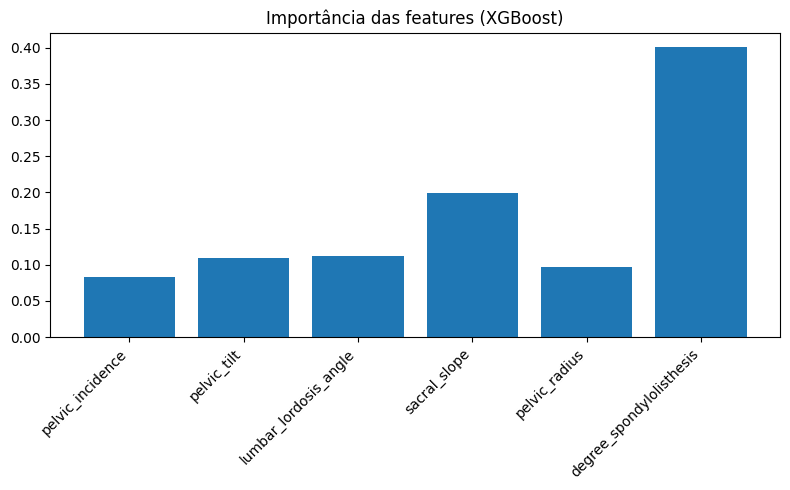


Pipeline executado com sucesso!


In [31]:
# Importância das features

importances = model.feature_importances_

plt.figure(figsize=(8,5))
plt.bar(range(len(importances)), importances)
plt.xticks(range(len(importances)), feat_cols, rotation=45, ha="right")

plt.title("Importância das features (XGBoost)")
plt.tight_layout()
plt.show()

print("\nPipeline executado com sucesso!")